Header, imports, load Iris

In [ ]:
#!/usr/bin/python
# -*- coding: utf-8 -*-

"""
=========================================================
The Iris Dataset – Dimensionality Reduction
=========================================================
This data set consists of 3 different types of irises'
(Setosa, Versicolour, and Virginica) petal and sepal
length, stored in a 150x4 numpy.ndarray.

The rows are the samples and the columns are:
Sepal Length, Sepal Width, Petal Length and Petal Width.

In the following, we illustrate 2D and 3D feature
reduction of the Iris dataset using PCA, Isomap and LLE.
"""

print(__doc__)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding

# Load the Iris dataset (all 4 features)
iris = datasets.load_iris()
X = iris.data          # shape (150, 4)
y = iris.target        # class labels 0, 1, 2

print("Data shape:", X.shape)



The Iris Dataset – Dimensionality Reduction
This data set consists of 3 different types of irises'
(Setosa, Versicolour, and Virginica) petal and sepal
length, stored in a 150x4 numpy.ndarray.

The rows are the samples and the columns are:
Sepal Length, Sepal Width, Petal Length and Petal Width.

In the following, we illustrate 2D and 3D feature
reduction of the Iris dataset using PCA, Isomap and LLE.

Data shape: (150, 4)


Projection Functions

In [ ]:
def PCAProjection(myArray, dim):
    return PCA(n_components=dim).fit_transform(myArray)

def LLEProjection(myArray, dim, n_neighbors=10):
    embedding = LocallyLinearEmbedding(n_components=dim,
                                       n_neighbors=n_neighbors)
    X_transformed = embedding.fit_transform(myArray)
    return X_transformed

def ISOMAPProjection(myArray, dim, n_neighbors=10):
    embedding = Isomap(n_components=dim, n_neighbors=n_neighbors)
    X_transformed = embedding.fit_transform(myArray)
    return X_transformed


Original 2D plot (sepal length vs sepal width)

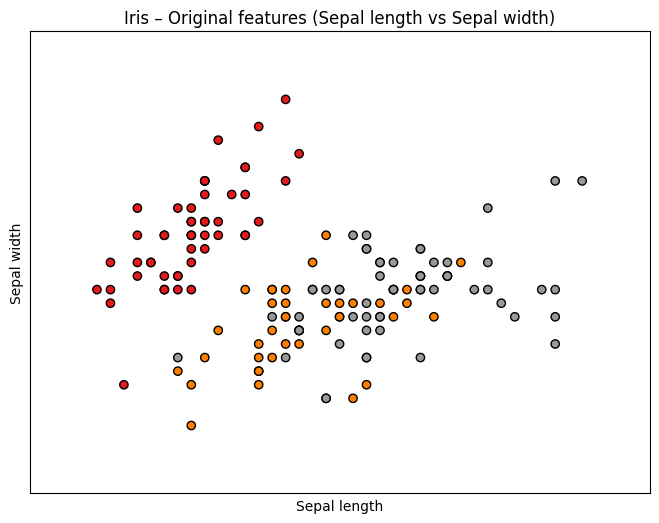

In [ ]:
# Original 2D view using the first two features
X_orig_2d = X[:, :2]  # sepal length, sepal width

x_min, x_max = X_orig_2d[:, 0].min() - .5, X_orig_2d[:, 0].max() + .5
y_min, y_max = X_orig_2d[:, 1].min() - .5, X_orig_2d[:, 1].max() + .5

plt.figure(figsize=(8, 6))
plt.scatter(X_orig_2d[:, 0], X_orig_2d[:, 1], c=y, cmap=plt.cm.Set1,
            edgecolor='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.title("Iris – Original features (Sepal length vs Sepal width)")
plt.show()


PCA: 2D and 3D

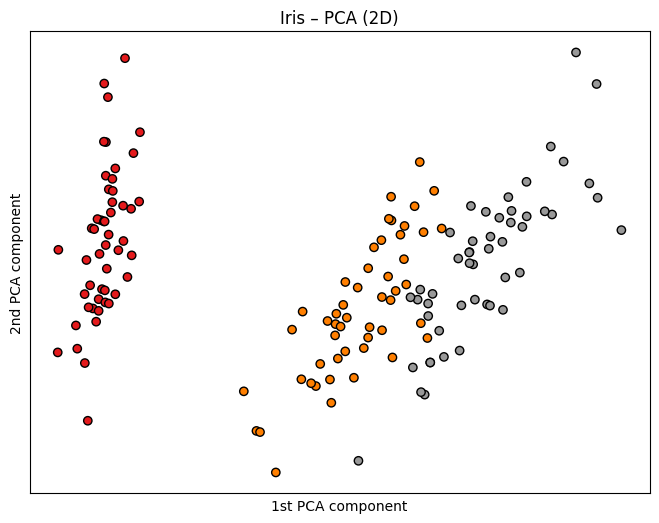

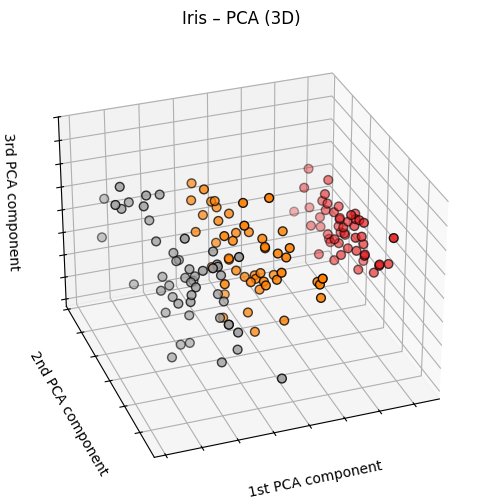

In [ ]:
# ===== PCA 2D =====
X_pca_2d = PCAProjection(X, dim=2)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap=plt.cm.Set1,
            edgecolor='k')
plt.xlabel('1st PCA component')
plt.ylabel('2nd PCA component')
plt.xticks(())
plt.yticks(())
plt.title("Iris – PCA (2D)")
plt.show()

# ===== PCA 3D =====
X_pca_3d = PCAProjection(X, dim=3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d', elev=-150, azim=110)

ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
           c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)

ax.set_title("Iris – PCA (3D)")
ax.set_xlabel("1st PCA component")
ax.set_ylabel("2nd PCA component")
ax.set_zlabel("3rd PCA component")

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()


Isomap: 2D and 3D

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


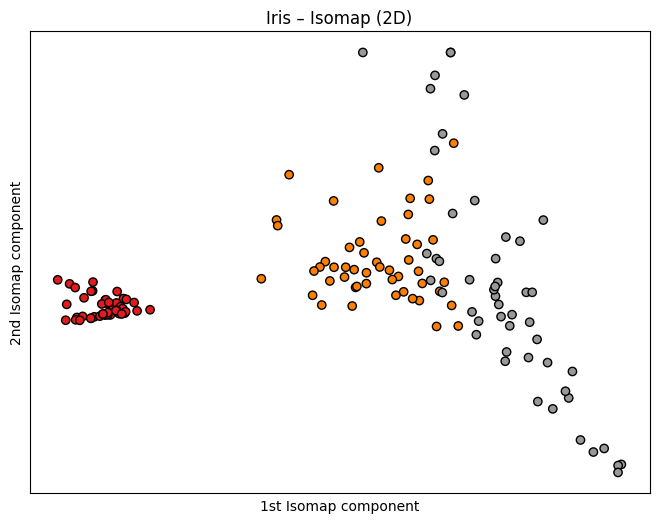

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


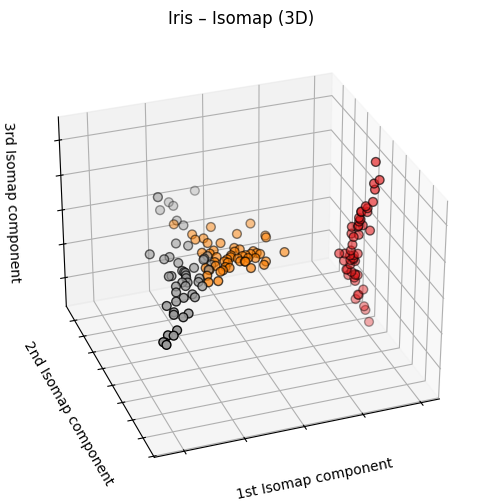

In [ ]:
# ===== ISOMAP 2D =====
X_iso_2d = ISOMAPProjection(X, dim=2, n_neighbors=10)

plt.figure(figsize=(8, 6))
plt.scatter(X_iso_2d[:, 0], X_iso_2d[:, 1], c=y, cmap=plt.cm.Set1,
            edgecolor='k')
plt.xlabel('1st Isomap component')
plt.ylabel('2nd Isomap component')
plt.xticks(())
plt.yticks(())
plt.title("Iris – Isomap (2D)")
plt.show()

# ===== ISOMAP 3D =====
X_iso_3d = ISOMAPProjection(X, dim=3, n_neighbors=10)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d', elev=-150, azim=110)

ax.scatter(X_iso_3d[:, 0], X_iso_3d[:, 1], X_iso_3d[:, 2],
           c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)

ax.set_title("Iris – Isomap (3D)")
ax.set_xlabel("1st Isomap component")
ax.set_ylabel("2nd Isomap component")
ax.set_zlabel("3rd Isomap component")

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()


LLE: 2D and 3D

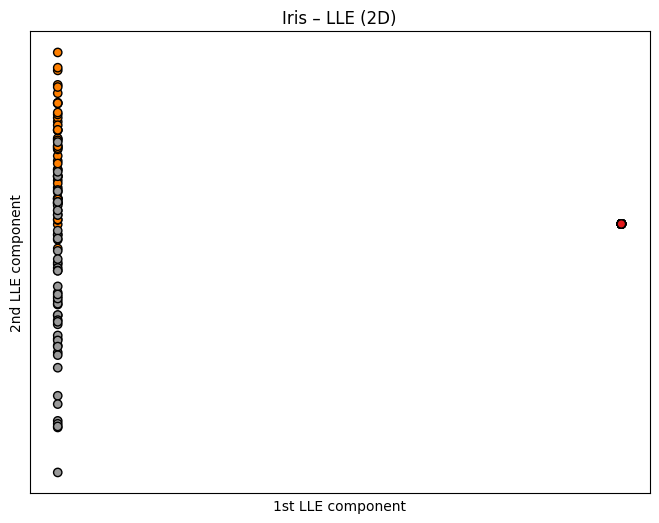

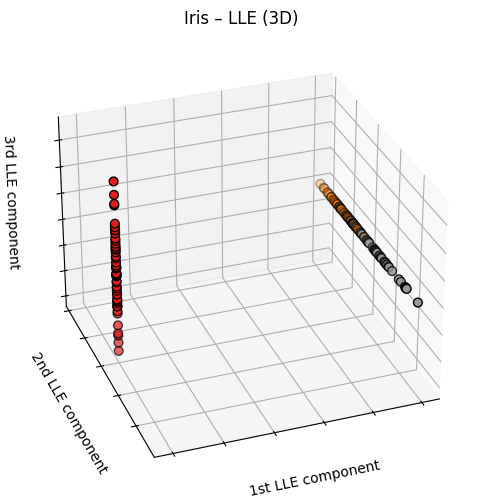

In [ ]:
# ===== LLE 2D =====
X_lle_2d = LLEProjection(X, dim=2, n_neighbors=10)

plt.figure(figsize=(8, 6))
plt.scatter(X_lle_2d[:, 0], X_lle_2d[:, 1], c=y, cmap=plt.cm.Set1,
            edgecolor='k')
plt.xlabel('1st LLE component')
plt.ylabel('2nd LLE component')
plt.xticks(())
plt.yticks(())
plt.title("Iris – LLE (2D)")
plt.show()

# ===== LLE 3D =====
X_lle_3d = LLEProjection(X, dim=3, n_neighbors=10)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d', elev=-150, azim=110)

ax.scatter(X_lle_3d[:, 0], X_lle_3d[:, 1], X_lle_3d[:, 2],
           c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)

ax.set_title("Iris – LLE (3D)")
ax.set_xlabel("1st LLE component")
ax.set_ylabel("2nd LLE component")
ax.set_zlabel("3rd LLE component")

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()
